# Probing Transformers: A Hands‑On Colab Tutorial

This notebook is a practical, visual tutorial on:

- What *representations* Transformers build across layers  
- What a *probe* is (and what it **isn't**)  
- How to run **layer‑wise linear probes** on frozen models  
- How to **inspect attention** and **hidden states** without fooling yourself

> **Core idea:** A probe is a simple model (often linear) trained on **frozen** Transformer activations to test whether some information is *linearly readable* from those activations.

## 0) Setup
Run this cell first. It installs libraries and sets a device.

In [ ]:
#@title Install dependencies (Colab)
!pip -q install -U transformers datasets accelerate scikit-learn matplotlib

import random, numpy as np, torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 18.9 MB/s eta 0:00:00
Device: cuda


## 1) What are we probing?

A Transformer builds a **sequence of hidden representations**:
- token embeddings
- layer 1..L outputs (attention + MLP blocks)

When we “probe a layer”, we:
1) Run text through the model with **no fine‑tuning**  
2) Extract hidden states at each layer  
3) Train a small classifier/regressor to predict a property from those hidden states  

### What probes can and can't tell you

**Probes can tell you:** whether information is *present in a readable form* (often linear).  
**Probes cannot prove:** that the model *uses* that information in its own predictions.

We’ll do a few sanity checks later to avoid over‑claiming.

## 2) Load a small Transformer (frozen)

We'll use `distilbert-base-uncased` because it runs fast and exposes:
- hidden states per layer
- attention maps

In [ ]:
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True,
    output_attentions=True,
).to(DEVICE)
model.eval()

print("Loaded:", MODEL_NAME)
print("Hidden size:", model.config.dim if hasattr(model.config, "dim") else model.config.hidden_size)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loaded: distilbert-base-uncased
Hidden size: 768


## 3) Warm‑up: tokenization and embedding intuition
Tokenization matters. If the label is encoded directly by surface form/tokenization, probes can “cheat”.

Text: Transformers are surprisingly good at learning structure.
Tokens: ['[CLS]', 'transformers', 'are', 'surprisingly', 'good', 'at', 'learning', 'structure', '.', '[SEP]']
Embedding matrix shape: torch.Size([10, 768])


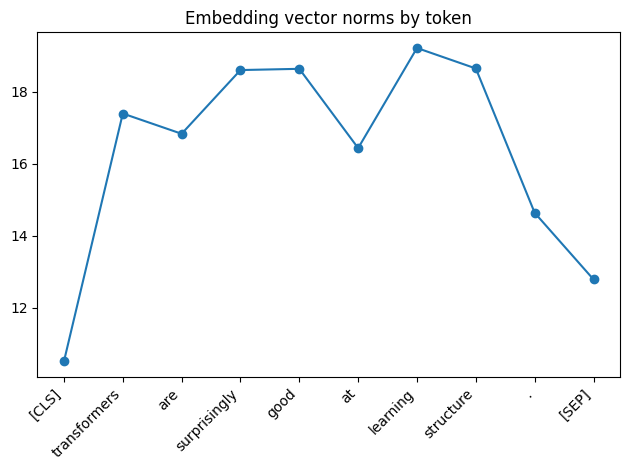

In [ ]:
import matplotlib.pyplot as plt

def show_tokenization(text: str):
    enc = tokenizer(text, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].tolist())
    return tokens, enc

text = "Transformers are surprisingly good at learning structure."
tokens, enc = show_tokenization(text)
print("Text:", text)
print("Tokens:", tokens)

with torch.no_grad():
    out = model(**{k:v.to(DEVICE) for k,v in enc.items()})
    hs = out.hidden_states  # (embeddings, layer1, ...)
    emb = hs[0][0]          # [seq, dim]

print("Embedding matrix shape:", emb.shape)

norms = emb.norm(dim=-1).detach().cpu().numpy()
plt.figure()
plt.plot(norms, marker="o")
plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
plt.title("Embedding vector norms by token")
plt.tight_layout()
plt.show()

## 4) Attention visualization (carefully)

Attention maps can be informative, but **attention is not explanation**.
Still, it can reveal local patterns, punctuation behavior, and aggregation.

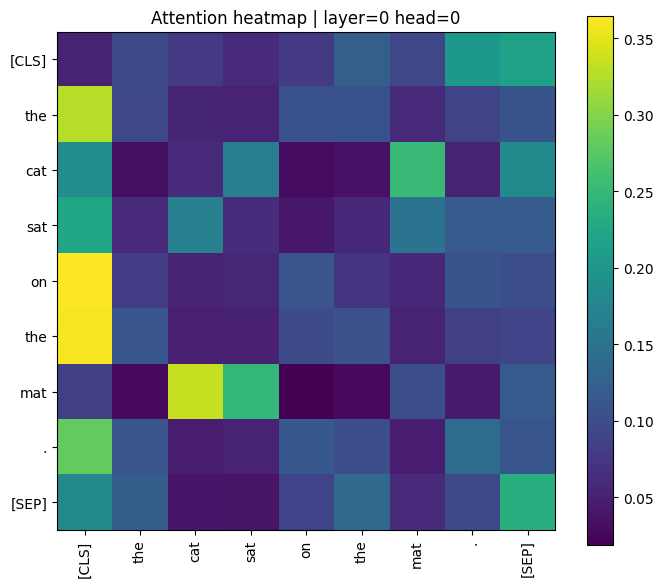

In [ ]:
def attention_heatmap(text: str, layer: int = 0, head: int = 0):
    enc = tokenizer(text, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].tolist())
    with torch.no_grad():
        out = model(**{k:v.to(DEVICE) for k,v in enc.items()})
    attn = out.attentions[layer][0, head].detach().cpu().numpy()  # [seq, seq]

    plt.figure(figsize=(7, 6))
    plt.imshow(attn)
    plt.xticks(range(len(tokens)), tokens, rotation=90)
    plt.yticks(range(len(tokens)), tokens)
    plt.title(f"Attention heatmap | layer={layer} head={head}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

attention_heatmap("The cat sat on the mat.", layer=0, head=0)

## 5) A real probe: layer‑wise linear probe for sentiment (SST‑2)

We will:
1) Freeze the Transformer  
2) Extract a **sentence vector** per layer via mean pooling  
3) Train a **Logistic Regression** probe per layer  
4) Plot accuracy vs layer

In [ ]:
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

ds = load_dataset("glue", "sst2")

# Keep it light
N_TRAIN = 2000
N_TEST  = 1000

train_texts = ds["train"]["sentence"][:N_TRAIN]
train_labels = np.array(ds["train"]["label"][:N_TRAIN])
test_texts = ds["validation"]["sentence"][:N_TEST]
test_labels = np.array(ds["validation"]["label"][:N_TEST])

print("Train:", len(train_texts), "Test:", len(test_texts))

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Train: 2000 Test: 872


### 5.1) Feature extraction: sentence vectors per layer
Mean pool over tokens (excluding padding).

In [ ]:
from torch.utils.data import DataLoader

def sentence_vectors_by_layer(texts, batch_size=32, max_length=96):
    all_by_layer = None
    dl = DataLoader(texts, batch_size=batch_size, shuffle=False)

    for batch_text in dl:
        enc = tokenizer(list(batch_text), return_tensors="pt", padding=True, truncation=True, max_length=max_length)
        enc = {k:v.to(DEVICE) for k,v in enc.items()}

        with torch.no_grad():
            out = model(**enc)
            hs = out.hidden_states  # tuple length = n_layers+1

        mask = enc["attention_mask"].unsqueeze(-1)  # [B, T, 1]
        denom = mask.sum(dim=1).clamp(min=1)        # [B, 1]

        batch_layer_vecs = []
        for layer_h in hs:
            pooled = (layer_h * mask).sum(dim=1) / denom
            batch_layer_vecs.append(pooled.detach().cpu().numpy())  # [B, D]

        if all_by_layer is None:
            all_by_layer = [v for v in batch_layer_vecs]
        else:
            for i in range(len(all_by_layer)):
                all_by_layer[i] = np.concatenate([all_by_layer[i], batch_layer_vecs[i]], axis=0)

    return all_by_layer

X_train_layers = sentence_vectors_by_layer(train_texts, batch_size=32)
X_test_layers  = sentence_vectors_by_layer(test_texts, batch_size=32)

print("Layers (incl embeddings):", len(X_train_layers))
print("Vector dim:", X_train_layers[0].shape[1])

Layers (incl embeddings): 7
Vector dim: 768


### 5.2) Train a probe per layer

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Layer 00 | acc=0.7294


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Layer 01 | acc=0.7454


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


...

Layer 04 | acc=0.7901


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Layer 05 | acc=0.8188


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Layer 06 | acc=0.8200


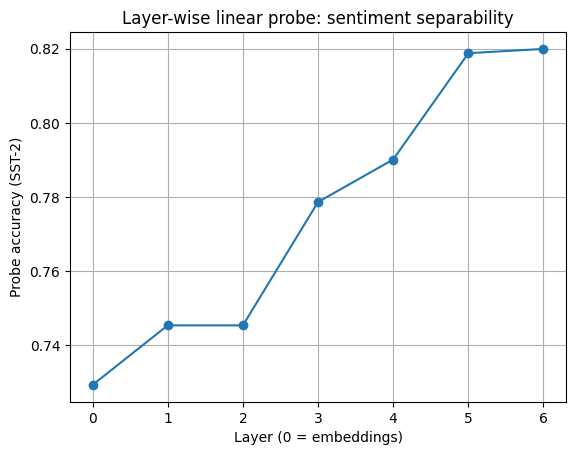

Best layer: 6 acc: 0.819954128440367


In [ ]:
accs = []
probes = []

for layer in range(len(X_train_layers)):
    clf = LogisticRegression(max_iter=2000, n_jobs=-1)
    clf.fit(X_train_layers[layer], train_labels)
    pred = clf.predict(X_test_layers[layer])
    acc = accuracy_score(test_labels, pred)
    accs.append(acc)
    probes.append(clf)
    print(f"Layer {layer:02d} | acc={acc:.4f}")

plt.figure()
plt.plot(range(len(accs)), accs, marker="o")
plt.xlabel("Layer (0 = embeddings)")
plt.ylabel("Probe accuracy (SST-2)")
plt.title("Layer-wise linear probe: sentiment separability")
plt.grid(True)
plt.show()

best_layer = int(np.argmax(accs))
print("Best layer:", best_layer, "acc:", float(accs[best_layer]))

## 6) Probe sanity checks (to avoid being fooled)

- **Shuffled labels** should drop toward chance (~50%)  
- Using only **a tiny training set** should reduce performance

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

best_layer = int(np.argmax(accs))

# Shuffled labels
y_shuf = train_labels.copy()
np.random.shuffle(y_shuf)
clf_shuf = LogisticRegression(max_iter=2000, n_jobs=-1)
clf_shuf.fit(X_train_layers[best_layer], y_shuf)
pred_shuf = clf_shuf.predict(X_test_layers[best_layer])
acc_shuf = accuracy_score(test_labels, pred_shuf)

# Tiny training set
idx = np.arange(len(train_labels))
tr_idx, _ = train_test_split(idx, train_size=200, random_state=SEED, stratify=train_labels)
clf_small = LogisticRegression(max_iter=2000, n_jobs=-1)
clf_small.fit(X_train_layers[best_layer][tr_idx], train_labels[tr_idx])
pred_small = clf_small.predict(X_test_layers[best_layer])
acc_small = accuracy_score(test_labels, pred_small)

print(f"Best layer {best_layer}:")
print("  Normal accuracy :", float(accs[best_layer]))
print("  Shuffled labels :", float(acc_shuf), "(should be ~0.5)")
print("  200 examples    :", float(acc_small), "(should drop vs full)")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Best layer 6:
  Normal accuracy : 0.819954128440367
  Shuffled labels : 0.5137614678899083 (should be ~0.5)
  200 examples    : 0.7878440366972477 (should drop vs full)


## 7) Token‑level probing demo: “Is this token capitalized?”

This is a clean token-level probe where the label exists in surface form.
We test where that signal stays linearly readable across layers.

**Note:** This is *not* deep linguistics — it’s a minimal demonstration of mechanics.

Examples: 46 Layers: 7


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(m

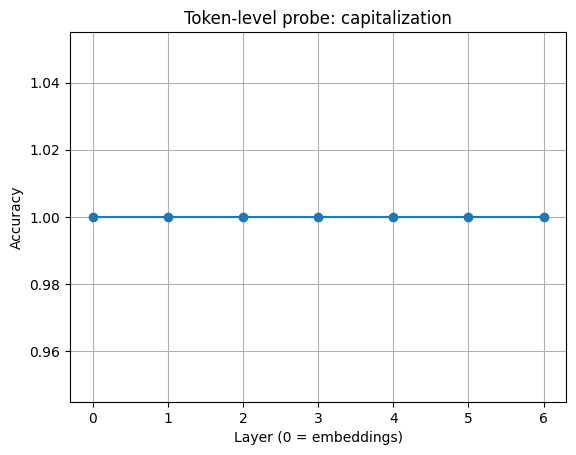

Best layer: 0 acc: 1.0


In [ ]:
import re
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

SYN_TEXTS = [
    "Alice went to New York City yesterday.",
    "bob drove to california in june.",
    "NASA launched Apollo missions decades ago.",
    "the quick Brown fox jumped over the lazy Dog.",
    "Paris is beautiful, but london is also great.",
]

def build_cap_examples(texts, max_length=64):
    X_layers = None
    y = []
    for t in texts:
        enc = tokenizer(t, return_tensors="pt", truncation=True, max_length=max_length)
        toks = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].tolist())
        enc = {k:v.to(DEVICE) for k,v in enc.items()}

        with torch.no_grad():
            out = model(**enc)
        hs = out.hidden_states  # (L+1, 1, T, D)

        for i, tok in enumerate(toks):
            clean = tok.replace("##", "")
            clean = re.sub(r"[^A-Za-z]", "", clean)
            if not clean:
                continue
            y.append(1 if clean[0].isupper() else 0)

            vecs = [hs[layer][0, i].detach().cpu().numpy() for layer in range(len(hs))]
            if X_layers is None:
                X_layers = [[] for _ in range(len(vecs))]
            for li, v in enumerate(vecs):
                X_layers[li].append(v)

    X_layers = [np.stack(vs, axis=0) for vs in X_layers]
    y = np.array(y)
    return X_layers, y

X_cap_layers, y_cap = build_cap_examples(SYN_TEXTS)
print("Examples:", len(y_cap), "Layers:", len(X_cap_layers))

idx = np.arange(len(y_cap))
tr, te = train_test_split(idx, test_size=0.35, random_state=SEED, stratify=y_cap)

cap_accs = []
for layer in range(len(X_cap_layers)):
    clf = LogisticRegression(max_iter=2000, n_jobs=-1)
    clf.fit(X_cap_layers[layer][tr], y_cap[tr])
    pred = clf.predict(X_cap_layers[layer][te])
    cap_accs.append(accuracy_score(y_cap[te], pred))

plt.figure()
plt.plot(range(len(cap_accs)), cap_accs, marker="o")
plt.xlabel("Layer (0 = embeddings)")
plt.ylabel("Accuracy")
plt.title("Token-level probe: capitalization")
plt.grid(True)
plt.show()

print("Best layer:", int(np.argmax(cap_accs)), "acc:", float(np.max(cap_accs)))

## 8) Next steps

Ideas to extend this tutorial:

- **POS tagging probes** (token-level; use labeled datasets)  
- **Syntactic depth probes** (tree distance / dependency depth)  
- **Semantic similarity** (STS-B) via cosine similarity of pooled states  
- **Interventions**: modify hidden states and see how downstream predictions change  

If you want to connect this to **representation geometry** (basins/clusters):
- cluster sentence vectors per layer
- track cluster stability across layers
- probe cluster IDs vs task labels (and vice versa)